# 07: Brownian rough-path message sensitivity

**Status, 8 September:** complete. Core acceptance, independent RoughPy verification, 48-condition main study, two four-class conditions and 42-condition independent confirmation passed their execution gates. Section 15 reports results and section 17 reconstructs every quoted number from stored files. Goursat-PDE rough-signature-kernel SVM remains outside core claims. Bibliographic entries: `../papers/references.bib`.

## Execution record and reproduction

Run stages in order. Preparation computes reusable rough-signature factors once before array jobs:

```bash
OUT=results/runs/brownian_message
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage acceptance
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage reference
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage prepare-pilot
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage pilot
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage prepare
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage main
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage four-class
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage aggregate
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage prepare --ensemble confirmation
python scripts/run_brownian_message_study.py --config configs/brownian_message.yaml --out $OUT --stage confirmation
```

Results are stored under `results/runs/brownian_message`. Core implementation uses explicit tensor algebra; recorded RoughPy comparison independently verifies basis order and signature values. Finite truncated signature kernel uses cached depth-four features. Goursat-PDE rough-path kernel requires a separate dependency decision and stays excluded from core claims.


## 1. Aim and role

Experiment asks which notions of closeness respond to controlled information inserted into Brownian rough paths, and how response changes with message type and amplitude. It studies path geometry directly rather than fitting a path-output model. Result complements experiments A and B: those use discrepancies as training objectives; this experiment first checks what information each discrepancy can see.

For original rough path $X^{(i)}$ and transformation $T_{\tau,\rho,s}$, define

$$
\widetilde X^{(i)}_{\tau,\rho,s}=T_{\tau,\rho,s}(X^{(i)}),
$$

where $\tau\in\{\mathrm{increment},\mathrm{area},\mathrm{combined}\}$ is message type, $\rho\geq0$ is normalized amplitude, and $s$ is temporal sign template. Direct comparison records $D(X^{(i)},\widetilde X^{(i)}_{\tau,\rho,s})$. Population comparison asks whether independent samples from unmodified and modified distributions can be separated.

Terms *loss*, *distance* and *metric* are kept distinct. MSE, $J_2$ and squared signature differences are nonnegative discrepancies. Their square roots may define metrics or pseudometrics under stated representations. Since no path predictor is trained here, report uses *discrepancy* unless metric axioms are established.


## 2. Data and fixed split

Local files are

```text
data/raw/BrownianStreamData/ensembles-10k/ensemble-0.npy
data/raw/BrownianStreamData/ensembles-10k/ensemble-1.npy
data/raw/BrownianStreamData/single-streams/stream-0.npy, ..., stream-99.npy
```

Each ensemble has shape $(10{,}000,2048,10)$ and dtype `float32`; each small file has shape $(2048,10)$. Source extraction code asserts original raw shape $(100{,}000,2048,10)$. Files are memory mapped and transformed in batches. Derived conditions are regenerated from config rather than stored as full copies. SHA-256 hashes identify raw files in every result record.

`ensemble-0.npy` supplies development and main results. `ensemble-1.npy` remains untouched until configuration, message grid, discrepancy definitions and analysis code are fixed. It supplies confirmation against an independent 10,000-path ensemble. The 100 single streams support loader and plotting tests only.

Dataset redistribution permission remains separate from mathematical use and must be confirmed before a public release.


## 3. Stream representation and Lévy area

Set $N=2048$, $h=1/N$ and $t_j=jh$. Stream $i$ is a sequence of step-two Lie increments

$$
\ell_j^{(i)}=(a_j^{(i)},A_j^{(i)})\in\mathfrak g^{(2)}(\mathbb R^4),\qquad 0\leq j<N,
$$

where $a_j^{(i)}\in\mathbb R^4$ is Brownian increment and $A_j^{(i)}\in\bigwedge^2\mathbb R^4$ has six antisymmetric Lévy-area coordinates. Thus stored width is $4+\binom42=10$. Coordinate path is reconstructed by

$$
W_0^{(i)}=0,\qquad W_{j+1}^{(i)}=W_j^{(i)}+a_j^{(i)}.
$$

For coordinates $p<q$, area over $[s,t]$ is, up to library basis convention,

$$
A_{s,t}^{pq}=\frac12\int_s^t\left[(W_u^p-W_s^p)\circ\mathrm dW_u^q-(W_u^q-W_s^q)\circ\mathrm dW_u^p\right].
$$

Independent Gaussian sampling is correct for $a_j\sim\mathcal N(0,hI_4)$ but not for six area coordinates conditional on $a_j$. Their joint conditional law is non-Gaussian and dependent (Wiktorsson, 2001). Brownian-bridge constructions approximate missing within-cell areas from additional random variables (Foster and Habermann, 2023). Supplied rough-path data is therefore retained rather than replaced by a new Gaussian generator.

Basis order and sign are obtained programmatically from `LieBasis(width=4, depth=2)` and stored in metadata. Column positions are never hard coded from an assumed ordering. Supplied example uses dyadic resolution 11, consistent with $2048=2^{11}$ increments.


## 4. Algebraic message insertion

A message increment is $m=(b,B)\in\mathfrak g^{(2)}(\mathbb R^4)$. At selected index $j$, composition uses truncated Campbell--Baker--Hausdorff product

$$
\widetilde\ell_j=\operatorname{BCH}_2(\ell_j,m)=\log\!\left(\exp(\ell_j)\exp(m)\right).
$$

Writing $\ell_j=(a_j,A_j)$ gives

$$
\operatorname{BCH}_2((a_j,A_j),(b,B))
=\left(a_j+b,\ A_j+B+\frac12[a_j,b]\right).
$$

BCH represents concatenation of original local rough increment with inserted message. Direct coordinate addition would define a different intervention and is excluded from primary study. Three message types are

$$
m_{\mathrm{inc}}=(b,0),\qquad
m_{\mathrm{area}}=(0,B),\qquad
m_{\mathrm{both}}=(b,B).
$$

Area-only insertion leaves first-level coordinate path exactly unchanged. Increment-only insertion also changes second level through bracket term $[a_j,b]/2$; this is required by geometric composition and is recorded rather than removed. Modified samples remain valid geometric step-two rough paths, while their probability law is intentionally changed by planted message.


## 5. Message direction, support and temporal templates

Primary directions are $u=e_1\in\mathbb R^4$ and $v=e_1\wedge e_2\in\bigwedge^2\mathbb R^4$. The standard four-dimensional Brownian rough-path law is rotationally invariant, so this direction is not theoretically privileged. Empirical coordinate-scale checks catch an obvious basis or simulation mismatch, while one alternate direction $(e_3,e_3\wedge e_4)$ tests whether the conclusion persists in the supplied finite ensemble. One fixed primary direction isolates message type without adding a direction sweep; the same direction is used for confirmation.

A needle occupies aligned block

$$
J=\{1024,1025,\ldots,1039\}.
$$

Sixteen increments span $1/128$ of full interval and align with dyadic data hierarchy. Midpoint placement avoids boundary effects. Fixed support prevents location variation from obscuring amplitude comparison.

Two sign templates separate net change from localized ordering:

$$
s_r^{\mathrm{net}}=1,\qquad 0\leq r<16,
$$

and

$$
s_r^{\mathrm{bal}}=\begin{cases}1,&0\leq r<8,\\-1,&8\leq r<16.\end{cases}
$$

Net template tests basic sensitivity. Balanced template is primary needle: direct message increments sum to zero, preventing endpoint displacement or total added area from becoming sole cue. For increment messages it creates a local excursion that returns at block end. For area messages it changes eight consecutive lifts by $+B$ and the next eight by $-B$. Any depth-two signature over an interval containing the full needle is unchanged: level one is untouched and direct level-two additions sum to zero. Within signature comparisons, a boundary inside the needle gives deterministic depth-two response; levels at least three can respond through temporal ordering for generic base paths.

Collaborator's ten scattered indices define an optional distributed-message extension after core study. They are excluded from primary matrix because scattered and localized support answer different questions.


## 6. Level-specific amplitude

First and second levels have different Brownian scales. Training portion of unmodified `ensemble-0.npy` supplies

$$
\sigma_1^2=\frac{1}{4Nn_{\mathrm{tr}}}\sum_{i,j}\|a_j^{(i)}\|_2^2,\qquad
\sigma_2^2=\frac{1}{6Nn_{\mathrm{tr}}}\sum_{i,j}\|A_j^{(i)}\|_2^2.
$$

Under Brownian and area conventions in section 3, expected scales are $\sigma_1=\sqrt h$ and $\sigma_2=h/2$. The 6,000-path training split gives $\sigma_1=0.0220955$ and $\sigma_2=0.000243787$. These values are stored under `scales.brownian` in each condition result; section 17 reads `main/conditions/net/increment/rho-0/result.json` and displays them beside theoretical values. Acceptance test 15 separately checks coordinatewise ratios on eight small example streams. Per-index message at support position $j=1024+r$ is

$$
b_r=\rho\sigma_1s_r u,\qquad B_r=\rho\sigma_2s_r v.
$$

Common normalized amplitude

$$
\rho\in\left\{0,\frac1{16},\frac18,\frac14,\frac12,1,2,4\right\}
$$

compares perturbations in units of each level's natural per-increment standard deviation. Existing $10^{-2}$ and $2\times10^{-2}$ area examples are tens of area standard deviations and serve only as implementation smoke checks. If a detectability transition lies between adjacent grid values, one geometric midpoint may be added using development data; addition and reason are logged before confirmation.


## 7. Path identities and class construction

Paired sensitivity uses each base path together with an on-the-fly modified copy. Same path identities enter every amplitude and message type, permitting paired comparisons.

Single-stream detection uses each base path once within a condition. Deterministic permutation with seed `20260903` partitions `ensemble-0.npy` into 6,000 training, 2,000 validation and 2,000 test identities. Each split is balanced: half remain unmodified and half receive one fixed message condition. Underlying Brownian identities are disjoint across classes and splits. This prevents a classifier from seeing original version of a modified test path. Class assignment and split remain fixed across discrepancies and amplitudes.

Binary tasks compare unmodified against one message type at one amplitude and template. Four-class task at $\rho=1$ compares unmodified, increment-only, area-only and combined messages using disjoint Brownian identities. Binary curves estimate sensitivity; four-class confusion matrix tests message-type discrimination.

`ensemble-1.npy` uses seed `20260904` and same proportions. Confirmation repeats paired direct curves and binary classification only for transition amplitudes selected from ensemble 0.


## 8. Coordinate-path discrepancies

For reconstructed paths $W$ and $\widetilde W$, set $e_j=W_j-\widetilde W_j$. Pointwise MSE and trapezoidal squared $L^2$ discrepancy are

$$
D_{\mathrm{MSE}}=\frac1{N+1}\sum_{j=0}^N\|e_j\|_2^2,\qquad
D_{J_2}=h\left(\frac{\|e_0\|_2^2+\|e_N\|_2^2}{2}+\sum_{j=1}^{N-1}\|e_j\|_2^2\right).
$$

Since $T=1$ and mesh is uniform, they differ only by endpoint half weights and normalization. Their agreement is a control rather than an independent scientific finding. Additional integral and supremum discrepancies are

$$
D_{L^1}=h\left(\frac{\|e_0\|_2+\|e_N\|_2}{2}+\sum_{j=1}^{N-1}\|e_j\|_2\right),\qquad
D_{L^\infty}=\max_{0\leq j\leq N}\|e_j\|_2.
$$

$H^1$ is excluded because Brownian paths lack square-integrable derivatives. First-level increment distance and second-level area distance are retained as diagnostics:

$$
D_{\Delta W}=\frac1N\sum_j\|a_j-\widetilde a_j\|_2^2,\qquad
D_A=\frac1N\sum_j\|A_j-\widetilde A_j\|_2^2.
$$

$D_A$ is a positive control, not a competitor: it reads planted area coordinates directly. Area-only messages must give zero coordinate-path discrepancies and positive $D_A$.


## 9. Signature discrepancies

Signature calculations use supplied step-two rough lift rather than piecewise-linear reconstruction from $W$ alone. All paths start from zero, so initial-value anchor is unnecessary. Time augmentation is omitted in core study: global signature represents geometric order up to reparameterization; fixed local blocks retain coarse time location.

### 9.1 Global depth-four signature

Let $S^{(k)}(X)$ be level $k$ of canonical signature extension of step-two geometric rough path, for $1\leq k\leq4$. With $\overline S^{(k)}=n_{\mathrm{tr}}^{-1}\sum_i S^{(k)}(X^{(i)})$, training-only level scale is

$$
q_k^2=\frac{1}{4^k n_{\mathrm{tr}}}\sum_i\left\|S^{(k)}(X^{(i)})-\overline S^{(k)}\right\|_2^2.
$$

Global discrepancy is

$$
D_{\mathrm{sig4}}^{\mathrm{global}}(X,Y)
=\sum_{k=1}^4\frac{\|S^{(k)}(X)-S^{(k)}(Y)\|_2^2}{4^k(q_k^2+\delta)},
$$

with fixed numerical $\delta$ used only to avoid division by zero. Coordinate mean $4^{-k}$ prevents feature count alone weighting a level; $q_k$ measures natural Brownian variation and prevents physical units or factorial decay from deciding level balance. Unscaled level components are saved so normalized result remains auditable.

### 9.2 Aligned and offset local depth-two signatures

Aligned partition contains 128 blocks of 16 increments,

$$I_b^{(0)}=[16bh,(16b+16)h],\qquad 0\leq b<128.$$

Needle $J$ equals aligned block $I_{64}^{(0)}$. A balanced area message has zero depth-two response on this block: level one is unchanged and $8B+8(-B)=0$. BCH cross terms also vanish because message has no level-one component.

Offset diagnostic shifts boundaries by eight increments,

$$I_b^{(8)}=[(8+16b)h,(24+16b)h],\qquad 0\leq b<127.$$

It covers increments 8 through 2039 and excludes eight boundary increments at each end. Needle straddles $I_{63}^{(8)}$ and $I_{64}^{(8)}$: one contains its $+B$ half and the other its $-B$ half, so both have nonzero depth-two response. Excluded boundary increments cannot affect this centred intervention.

For offset $o\in\{0,8\}$ with $B_0=128$ and $B_8=127$, define the training mean at block $b$ by

$$
\overline S_{k,o,b}=\frac1{n_{\mathrm{tr}}}\sum_i S_{I_b^{(o)}}^{(k)}(X^{(i)}),
$$

and the pooled within-block scale by

$$
q_{k,o}^2=\frac1{4^k n_{\mathrm{tr}}B_o}\sum_{i,b}\left\|S_{I_b^{(o)}}^{(k)}(X^{(i)})-\overline S_{k,o,b}\right\|_2^2.
$$

The local discrepancy is

$$
D_{\mathrm{sig2}}^{(o)}(X,Y)
=\frac1{B_o}\sum_b\sum_{k=1}^2\frac{\|S_{I_b^{(o)}}^{(k)}(X)-S_{I_b^{(o)}}^{(k)}(Y)\|_2^2}{4^k(q_{k,o}^2+\delta)}.
$$

Report full-partition average and contribution from blocks intersecting $J$. Aligned versus offset response isolates partition-boundary sensitivity.

### 9.3 Response-derived signature family

Ferrucci, Perrée and Lyons (2026, Problem 0.1) bound terminal responses of linear controlled differential equations whose coefficient matrices have operator norm at most $r$. Expanding a linear response in signature coordinates and applying the triangle inequality gives the finite proxy

$$
U_{r,L}^{\mathrm{global}}(X,Y)
=\sum_{k=1}^{L}r^k\left\|S^{(k)}(X)-S^{(k)}(Y)\right\|_1.
$$

Weight $r^k$ arises because a level-$k$ response term contains $k$ coefficient matrices. Coordinate $\ell^1$ arises from summing absolute wordwise contributions. This experiment sets $L=4$ and reports the fixed family $r\in\{0.5,1,2\}$ in supplied dimensionless coordinate convention. Values respectively suppress, retain and emphasize higher levels; no member is selected after observing detection results.

Local counterpart restarts the finite response proxy on each block,

$$
U_{r,2}^{(o)}(X,Y)=\frac1{B_o}\sum_b\sum_{k=1}^{2}r^k
\left\|S_{I_b^{(o)}}^{(k)}(X)-S_{I_b^{(o)}}^{(k)}(Y)\right\|_1.
$$

It measures average blockwise response sensitivity rather than one system run over the full path. Brownian paths require rough differential equation theory; bounded-variation infinite-tail proof in notebook 05 does not transfer unchanged. Present quantity is therefore reported as a depth-limited linear-response proxy.

### 9.4 Finite truncated signature kernel

For $L=4$ and fixed $\lambda=1$, define explicit feature map and linear kernel

$$
\Phi_{L,\lambda}(X)=\left(1,\lambda S^{(1)}(X),\ldots,\lambda^L S^{(L)}(X)\right),\qquad
K_{L,\lambda}(X,Y)=\langle\Phi_{L,\lambda}(X),\Phi_{L,\lambda}(Y)\rangle.
$$

Normalize and take induced Hilbert-space distance,

$$
\overline K(X,Y)=\frac{K(X,Y)}{\sqrt{K(X,X)K(Y,Y)}},\qquad
d_{K,L}(X,Y)=\sqrt{\max\{0,2-2\overline K(X,Y)\}}.
$$

Scalar level ensures nonzero feature norm. Setting $\lambda=1$ adds no fitted scale parameter. This kernel uses cached finite signatures, so it is a normalized angular comparison of depth-four signature features. It differs from variance-normalized Euclidean signature discrepancy in §9.1 through level weighting and radial normalization.

### 9.5 Goursat-PDE rough-signature kernel (optional)

Salvi et al. (2021) identify full signature inner product with solution of a Goursat PDE and extend construction to geometric rough paths. That solver can incorporate supplied rough lift without explicit finite tensor truncation. It requires a separate rough-kernel backend and fixed numerical resolution, so it remains outside current dependency-free run. Finite kernel in §9.4 must not be described as this PDE kernel.


### 9.6 Exact construction and implementation map

This subsection removes any ambiguity about the object supplied to the losses. Message construction, rough signatures, discrepancies and 1-nearest-neighbour utilities are implemented in `../src/pathloss/brownian_messages.py`; caching, paired analysis, detection rules, confidence intervals and aggregation are implemented in `../src/pathloss/brownian_message_study.py`. The frozen experiment is `../configs/brownian_message.yaml` and its runner is `../scripts/run_brownian_message_study.py`. One stream is a sequence of step-two Lie increments

$$g_j=(a_j,A_j),\qquad a_j\in\mathbb R^4,\quad A_j\in\bigwedge^2\mathbb R^4,$$

where $a_j$ is the Brownian increment and $A_j$ is the supplied antisymmetric Lévy-area coordinate. After embedding $A_j$ as an antisymmetric $4\times4$ tensor, the tensor exponential of one increment begins

$$\exp_{\otimes}(g_j)^{(0)}=1,\qquad \exp_{\otimes}(g_j)^{(1)}=a_j,\qquad \exp_{\otimes}(g_j)^{(2)}=A_j+\tfrac12a_j^{\otimes2}.$$

Levels three and four are obtained from the same truncated tensor exponential. For increments $u,\ldots,v-1$, the code forms the canonical extension by the ordered Chen product

$$S_{[u,v]}^{\leq L}(X)=\bigotimes_{j=u}^{v-1}\exp_{\otimes}(g_j),\qquad S_{[u,v]}^{(k)}(X)\in\mathbb R^{4^k}.$$

Coordinates use the fixed lexicographic tensor-word basis. Every method first constructs the signature of $X$ and the signature of $Y$, then compares these two feature collections. The residual path $X-Y$ is not signed. This choice retains the ordered iterated-integral information of each stream. All paths start at zero, so an initial-value anchor would be identically zero. The core study has no time channel: global signatures retain geometric order up to reparameterization, while the indexed local blocks retain coarse temporal location.

For the global and local variance-normalized losses in §§9.1–9.2, the numerical stabilizer is fixed at $\delta=10^{-12}$. The formulae there can be written as Euclidean feature distances:

$$\Psi_{\mathrm g}(X)=\bigoplus_{k=1}^{4}\frac{S^{(k)}(X)}{\sqrt{4^k(q_k^2+\delta)}},\qquad D_{\mathrm{sig4}}^{\mathrm{global}}(X,Y)=\|\Psi_{\mathrm g}(X)-\Psi_{\mathrm g}(Y)\|_2^2,$$

$$\Psi_o(X)=\bigoplus_{b=0}^{B_o-1}\bigoplus_{k=1}^{2}\frac{S_{I_b^{(o)}}^{(k)}(X)}{\sqrt{B_o4^k(q_{k,o}^2+\delta)}},\qquad D_{\mathrm{sig2}}^{(o)}(X,Y)=\|\Psi_o(X)-\Psi_o(Y)\|_2^2.$$

The square roots of these squared discrepancies are used as distances. The block index $b$ is retained in $\Psi_o$: a block is compared only with the block at the same location. Training means and scales $q_k^2,q_{k,o}^2$ are estimated from unmodified training identities and then frozen. The $4^{-k}$ factor takes a coordinate mean; the $q^{-2}$ factor puts ordinary Brownian variability at different levels on comparable scales. This scaling is a project design choice rather than an intrinsic part of the signature, so the fitted scales and unscaled level contributions are stored.

For the response-derived family in §9.3, no variance normalization is applied. Define

$$\Psi_{r,L}^{\mathrm{resp}}(X)=\bigoplus_{k=1}^{L}r^kS^{(k)}(X).$$

Then $U_{r,L}^{\mathrm{global}}(X,Y)=\|\Psi_{r,L}^{\mathrm{resp}}(X)-\Psi_{r,L}^{\mathrm{resp}}(Y)\|_1$. For a local form, the feature vector concatenates ordered block-level coordinates $B_o^{-1}r^kS_{I_b^{(o)}}^{(k)}(X)$, so its coordinate $\ell^1$ distance is exactly the block average in §9.3. The global depth is four and local depth is two. The pre-specified values $r\in\{0.5,1,2\}$ are all reported in paired analysis; only global $r=1$ is used for detection. The dependence of $U_{r,L}$ on coordinate units is accepted here because the supplied dimensionless coordinate convention is held fixed. Notebook 05 §§5.4–5.7 contains the detailed response-bound derivation and its assumptions.

For the finite kernel in §9.4, the code forms the raw depth-four feature $\Phi_{4,1}(X)=(1,S^{(1)}(X),\ldots,S^{(4)}(X))$, normalizes it to unit Euclidean length, and computes ordinary Euclidean distance between the normalized vectors. This is exactly $d_{K,4}$ in §9.4. It is a metric on those normalized finite feature vectors and can be a pseudometric on paths when two paths have the same representation. The natural-scale normalization in §10 is applied afterwards and does not change nearest-neighbour identities. This finite explicit-feature kernel is separate from the unimplemented Goursat-PDE rough-signature kernel in §9.5.

| Stored name | Exact object | Depth and localization | Norm and scaling | Analysis role |
|---|---|---|---|---|
| global | $\sqrt{D_{\mathrm{sig4}}^{\mathrm{global}}}$ | depth 4, full stream | Euclidean; training variance normalized | paired and detection |
| local_aligned | $\sqrt{D_{\mathrm{sig2}}^{(0)}}$ | depth 2, 128 aligned blocks | Euclidean; pooled training variance normalized | paired and detection |
| local_offset | $\sqrt{D_{\mathrm{sig2}}^{(8)}}$ | depth 2, 127 offset blocks | Euclidean; pooled training variance normalized | paired and detection |
| response_global_r0p5, response_global_r1, response_global_r2 | $U_{r,4}^{\mathrm{global}}$ | depth 4, full stream | raw coordinate $\ell^1$ with weights $r^k$ | paired; $r=1$ also detection |
| response_local_aligned_r* | $U_{r,2}^{(0)}$ | depth 2, 128 aligned blocks | raw coordinate $\ell^1$ with weights $r^k$; block average | paired |
| response_local_offset_r* | $U_{r,2}^{(8)}$ | depth 2, 127 offset blocks | raw coordinate $\ell^1$ with weights $r^k$; block average | paired |
| signature_kernel_truncated | $d_{K,4}$ | depth 4, full stream | normalized raw finite signature feature | paired and detection |

Accordingly, §10 uses $d_D=\sqrt D$ for the two squared variance-normalized discrepancies, $d_D=U_{r,L}$ for the response-derived discrepancies, and $d_D=d_{K,4}$ for the truncated-kernel discrepancy. A quantity that is already a distance receives no additional square root.


## 10. Primary paired sensitivity

For each discrepancy $D$, use distance scale $d_D=\sqrt{D}$ when $D$ is squared. A fixed derangement $\pi$ of unmodified path identities defines natural between-path scale

$$
c_D=\operatorname{median}_i d_D(X^{(i)},X^{(\pi(i))}).
$$

Normalized message sensitivity is

$$
R_D(\tau,\rho,s)=\frac{\operatorname{median}_i d_D\left(X^{(i)},\widetilde X^{(i)}_{\tau,\rho,s}\right)}{c_D}.
$$

$R_D=1$ means planted modification is as large under $D$ as typical difference between two independent Brownian streams. Raw median, interquartile range and 95% paired bootstrap interval are stored beside normalized value. Bootstrap resamples path identities with seed `20260905`; 1,000 replicates suffice for plots and intervals.

Primary plots show $R_D$ against $\rho$ separately for three message types and two templates. Levelwise signature components remain visible. Required structural checks are: area-only messages give $R_D=0$ for coordinate-path discrepancies; net area messages change global and local level two; balanced area messages leave global level two and aligned local depth two unchanged and give nonzero offset local depth-two response. Global levels three or four are expected to respond for generic Brownian base paths and are summarized across paths rather than required path by path.


## 11. Single-stream detection

Paired analysis assumes exact original is available. Detection analysis supplies one stream and asks whether message status can be inferred amid Brownian variability. Primary classifier is fixed 1-nearest neighbour because it can use every discrepancy without learning a new representation or introducing classifier hyperparameters. For test stream $x$,

$$
\widehat y(x)=y_{i^\star},\qquad i^\star=\operatorname*{arg\,min}_{i\in\mathrm{train}}d_D(x,X^{(i)}).
$$

Ties use smallest training index. For binary ROC AUC, continuous score is difference between nearest class-zero and class-one distances,

$$
s_D(x)=\min_{i:y_i=0}d_D(x,X^{(i)})-\min_{i:y_i=1}d_D(x,X^{(i)}).
$$

Positive score favours message class. Report balanced accuracy, ROC AUC, confusion matrix and 95% bootstrap interval over test identities. Chance balanced accuracy is $1/2$ for binary task and $1/4$ for four-class task. At $\rho=0$, labels are independent of path law; above-chance performance triggers split and leakage audit before any message result is interpreted. Aggregation excludes $\rho=0$ from transition candidates and withholds an operational transition for any representation whose zero-amplitude lower confidence bound exceeds $1/2$.

Operational detection amplitude is smallest grid value whose 95% lower confidence bound for binary balanced accuracy exceeds $1/2$. It is sample-size and protocol dependent and is reported with full curve. Ensemble 1 confirms that amplitude and preceding lower grid value.

Finite truncated signature kernel enters fixed 1-nearest-neighbour comparison through $d_{K,4}$. Response-derived detection uses $U_{1,4}^{\mathrm{global}}$; $r=0.5$ and $r=2$ remain paired-sensitivity diagnostics to avoid tripling classification cost. Optional Goursat-PDE rough-signature-kernel SVM uses normalized precomputed kernel, fixed $C=1$ and same split identities. A 100-stream timing benchmark fixes feasible sample count before labels are evaluated.

Unsupervised clustering is descriptive only: adjusted Rand index may be reported for fixed two-cluster kernel $k$-means, with seed and initialization count fixed. It cannot establish absence of signal when clusters fail.


## 12. Acceptance tests

Main run requires one machine-readable report with every check true:

1. file shapes are $(10{,}000,2048,10)$, dtype is `float32`, and hashes match configuration;
2. library basis exposes four level-one and six level-two elements with recorded order and sign;
3. `resolution=11` round trip preserves unmodified increments and signatures within stated tolerance;
4. $\rho=0$ leaves every stored coordinate unchanged bit for bit;
5. perturbation changes only selected path identities and sixteen selected time rows;
6. area-only BCH leaves all four first-level increments and reconstructed coordinate paths unchanged;
7. balanced increment message returns reconstructed path to original after message block within $10^{-6}$;
8. BCH output agrees with independent RoughPy or RoughPy-JAX composition on random small cases;
9. net area message changes aggregate level-two area by prescribed amount; balanced area message has zero direct aggregate addition;
10. direct discrepancies are finite, nonnegative and symmetric on random pairs; identical-path values are zero within tolerance;
11. finite truncated kernel has normalized diagonal one and induced self-distance zero within tolerance; response-derived self-distance is zero;
12. train, validation and test path identities are disjoint and class counts are balanced;
13. all scales use unmodified training paths only;
14. large-amplitude smoke checks respect template algebra: a net area message gives positive $D_A$, global level-two, aligned local depth-two, response-derived and finite-kernel responses; a balanced area message gives positive $D_A$ and offset local depth-two response while global level two and aligned local depth two remain zero within tolerance; median global depth-three or depth-four and finite-kernel responses over sampled Brownian paths must exceed numerical tolerance;
15. each first-level coordinate standard deviation satisfies $|\sigma_{1,r}/\sqrt h-1|\leq0.05$ and each area-coordinate standard deviation satisfies $|\sigma_{2,r}/(h/2)-1|\leq0.05$ under recorded basis convention.

Acceptance thresholds are fixed in config. Template-specific zero responses are required outcomes. A failed nonzero gate or nonzero value where algebra predicts zero triggers implementation, basis or numerical repair; thresholds remain unchanged.


## 13. Run order and compute gates

1. **Loader audit:** inspect shapes, hashes, basis order, empirical first-level and area scales.
2. **Perturbation acceptance:** run analytic and independent-library checks on small synthetic examples and downloaded single streams.
3. **Smoke test:** use 100 small streams, all three message types, both templates, $\rho\in\{0,1,4\}$. Evaluate aligned and offset local partitions. Generate plots verifying intended first-level, area and template-specific signature responses.
4. **Pilot:** use first 500 permuted ensemble-zero identities across full amplitude grid. Record discrepancy runtime, monotonicity and numerical failures. Pilot changes implementation or compute batching, not message grid or outcome definitions. Optional rough-kernel timing remains separate.
5. **Main paired study:** process all 10,000 ensemble-zero paths in memory-mapped batches.
6. **Main detection study:** run fixed 1-nearest-neighbour comparisons on prespecified split. Explicit finite-signature, response-derived $r=1$ and truncated-kernel features may use all paths. Optional rough-kernel SVM uses sample count fixed by timing gate.
7. **Confirmation:** open ensemble one only after main configuration is frozen. Repeat direct curves and prespecified transition conditions.
8. **Optional extensions:** alternate direction, scattered temporal code and message-location classification enter only after core outputs are complete.

Every result directory stores configuration, git SHA, raw hashes, split identities, basis map, scales, runtime, peak memory and software versions. Kernel matrices may be cached by path identity and representation but never shared across incompatible amplitudes or message types.


## 14. Required figures and interpretation

Core output contains:

1. example reconstructed coordinate paths before and after each message, plus first-level and area increment differences;
2. normalized paired sensitivity curves $R_D(\rho)$ with uncertainty;
3. global signature level contributions and aligned-versus-offset local message-block contributions;
4. binary balanced-accuracy curves and operational detection amplitudes;
5. four-class confusion matrix at $\rho=1$;
6. ensemble-zero versus ensemble-one confirmation table;
7. compute table for direct features, response-derived losses, truncated kernel and optional rough kernel.

Outcome meanings are fixed before run:

| result | interpretation |
|---|---|
| area-only: coordinate distances zero, at least one lift-aware discrepancy positive | first-level closeness identifies paths that differ as rough paths |
| paired signature response positive, classifier at chance | message exists relative to exact original but is small relative to population variability |
| balanced area: global level two and aligned local depth two zero; generic global higher-level and offset local depth-two responses positive | exact depth-two cancellation is caused by block alignment; higher order or a boundary inside needle can restore response |
| $D_A$ succeeds while global depth four, offset local depth two, response-derived loss and truncated kernel all fail | finite signature weighting or truncation suppresses available information |
| increment messages detected similarly by coordinate and signature methods | higher-order representation adds no sensitivity for that condition |
| $\rho=0$ classifier exceeds chance beyond sampling uncertainty | null control fails; audit split and pipeline, then withhold representation until an independent split is checked |
| ensemble-one result fails to reproduce ensemble-zero transition | sensitivity claim lacks independent-ensemble support |

Area-only outcome is a designed structural example rather than general superiority claim: coordinate path deliberately omits changed variable. Main empirical content is amplitude dependence, balanced cancellation, global versus local response and detection amid independent Brownian variability.


## 15. Results

The independent RoughPy calculation agrees with the explicit step-two signature calculation to approximately $1.73\times10^{-18}$, below fixed tolerance $10^{-9}$. Main study contains 48 binary conditions and two four-class conditions on ensemble zero. Confirmation contains 42 binary conditions on untouched ensemble one. Sources: `acceptance/reference.json`, `main/summary.json`, `main/four_class/{net,balanced}/result.json` and `confirmation/summary.json`; section 17 reconstructs all counts.

### 15.1 Paired discrepancy response

Area-only intervention leaves coordinate paths unchanged. MSE, $J_2$, $L^1$, $L^\infty$ and direct first-level increment discrepancy are therefore exactly zero. Lift-aware discrepancies respond because step-two area changes. Balanced area intervention cancels within each aligned 16-step block: aligned local depth-two discrepancy is zero to numerical precision, while an eight-step offset moves a window boundary through the message and produces positive response. Global depth four responds through levels three and four despite level-two cancellation. This verifies that signature sensitivity depends on truncation and interval placement. Source: `main/paired_summary.csv`; section 17 displays balanced area rows.

Paired sensitivity is stable across supplied ensembles. Among 600 comparison entries above $10^{-8}$, median relative change in normalized median discrepancy is $0.25\%$ and maximum is $2.81\%$. Intervention-to-distance map therefore reproduces more closely than population classification thresholds. Source: `confirmation_comparison.csv`; section 17 recomputes all three numbers.

### 15.2 Binary single-stream detection

Ensemble-zero raw area coordinates fail their zero-amplitude control: balanced accuracy $0.5275$ with interval $[0.5069,0.5483]$. All 11 confirmation controls include chance $1/2$, including raw area at $0.5005$ with interval $[0.4792,0.5225]$. First result is consistent with a split-specific false positive. Fixed aggregation withholds main raw-area transitions, so six raw-area thresholds observed only on confirmation remain descriptive. Sources: `main/summary.json` and `confirmation/summary.json`; section 17 displays both null-control tables and counts confirmation-only raw-area transitions.

Every one of 29 valid main transitions reappears on confirmation: 23 at the same amplitude and six at another tested amplitude. For net increment and combined messages, direct increment features cross at $0.5$ on both ensembles; MSE, $J_2$, $L^1$ and offset local signatures cross at $1$; global depth-four signatures and truncated signature kernels cross at $2$. Aligned local signatures cross at $0.25$ on main and $0.5$ on confirmation, retaining a factor-two to factor-four sensitivity advantage over MSE and $J_2$. $L^\infty$ moves from $2$ to $1$. Source: transition arrays in both `summary.json` files; section 17 constructs full joined table and agreement counts.

Response-derived global signature first crosses at $2$ on main and $0.5$ on confirmation. Confirmation at $1$ falls below the rule before crossing again at $2$ and $4$, so the $0.5$ entry is an isolated crossing rather than a stable transition. Curve-level evidence supports reliable response from $2$; the pre-specified first-crossing threshold is ensemble-sensitive. Sources: `confirmation/conditions/net/{increment,combined}/rho-*/result.json`; section 17 displays balanced accuracy and lower confidence bound at every tested confirmation amplitude.

Balanced increment and combined messages reproduce the same hierarchy exactly: direct increments cross at $0.5$, offset local signatures at $1$, aligned local signatures at $2$, and $L^\infty$ at $4$. Net area-only messages give an aligned-local transition at $4$ on both ensembles. Pointwise and integral coordinate losses remain at chance because their observed coordinate path is unchanged. MSE and $J_2$ behave almost identically for coordinate-changing messages, as expected on this uniform time grid. Source: transition arrays in both `summary.json` files, displayed in section 17.

### 15.3 Four-class message type

Four-class analysis at $\rho=1$ uses ensemble zero and class order: unmodified, increment, area, combined. Chance balanced accuracy is $0.25$. For net messages, aligned local signature is strongest at $0.3995$ with interval $[0.3779,0.4213]$; offset local signature gives $0.3175$ and direct increments $0.2965$. For balanced messages, offset local signature is strongest at $0.314$, followed by direct increments at $0.289$. Aligned windows lose balanced-message information through exact block cancellation, while offset windows retain it. Four-class results have no second-ensemble confirmation and remain descriptive. Sources: `main/four_class/net/result.json` and `main/four_class/balanced/result.json`; section 17 displays every representation with confidence interval.

### 15.4 Interpretation

Results separate three meanings of closeness. Coordinate norms compare observed first-level paths and assign zero discrepancy to area-only messages. Global signatures detect rough-path changes but can dilute a short intervention within whole-stream variability. Local signatures can isolate short changes, with sensitivity controlled by interval boundaries. Signature methods are useful when relevant structure includes higher-order interactions or local ordering; their advantage depends on representation design. Uniform sampling leaves MSE and $J_2$ effectively equivalent in this study.


## 16. Scope limits

Study uses one supplied four-dimensional Brownian rough-path law, one step resolution, one primary message direction and deterministic BCH intervention. It does not estimate universal detection thresholds. Thresholds depend on sample size, message support, representation scaling and classifier.

Finite signatures and kernel numerical approximations retain limited information. Signature uniqueness results for complete signatures do not imply that chosen truncation or solver detects every finite message. Conversely, area-only construction ensures first-level coordinate losses cannot respond; this is a property of supplied information rather than optimizer performance.

This experiment does not train a path-to-path operator. It supplies evidence about path-space discrepancies that may later be used as losses or representations in operator learning.


## 17. Stored-result view

Cells below read acceptance, condition results, aggregate tables and figures produced by runner. They reconstruct every observed number quoted in sections 6 and 15 from named files. Missing files are reported without treating an unrun stage as a failed result. Experiment logic remains in `../src/pathloss/`; notebook only presents stored outputs. The main evidence files are `../results/runs/brownian_message/main/summary.json`, `main/paired_summary.csv`, `main/four_class/{net,balanced}/result.json`, `confirmation/summary.json` and `confirmation_comparison.csv`; acceptance and independent reference checks are under `../results/runs/brownian_message/acceptance/`.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULT_ROOT = Path("../results/runs/brownian_message")
acceptance_path = RESULT_ROOT / "acceptance" / "acceptance.json"
reference_path = RESULT_ROOT / "acceptance" / "reference.json"

for label, path in (("core acceptance", acceptance_path), ("RoughPy reference", reference_path)):
    if path.exists():
        report = json.loads(path.read_text())
        print(label, {"passed": report.get("passed"), "checks": report.get("checks")})
    else:
        print(label, "pending")


core acceptance {'passed': True, 'checks': {'area_coordinate_scales': True, 'area_message_preserves_first_level': True, 'balanced_area_aligned_depth2_zero': True, 'balanced_area_offset_depth2_positive': True, 'balanced_reduction_consistent': True, 'basis_dimensions': True, 'finite': True, 'first_coordinate_scales': True, 'response_signature_self_distance_zero': True, 'rho_zero_bitwise': True, 'shape': True, 'support_only': True, 'truncated_kernel_self_distance_zero': True}}
RoughPy reference {'passed': True, 'checks': {'basis_dimension': True, 'modified_signature': True, 'original_signature': True}}


In [2]:
# Empirical scales quoted in section 6. This representative condition stores
# scales computed once from 6,000 unmodified training identities.
scale_path = RESULT_ROOT / "main" / "conditions" / "net" / "increment" / "rho-0" / "result.json"
if scale_path.exists():
    scale_report = json.loads(scale_path.read_text())
    brownian_scale = scale_report["scales"]["brownian"]
    step_count = 2048
    scale_rows = [
        {
            "level": "first",
            "observed pooled scale": brownian_scale["sigma_first"],
            "theoretical scale": step_count ** -0.5,
            "coordinate standard deviations": brownian_scale["first_std"],
        },
        {
            "level": "area",
            "observed pooled scale": brownian_scale["sigma_area"],
            "theoretical scale": 1 / (2 * step_count),
            "coordinate standard deviations": brownian_scale["area_std"],
        },
    ]
    print("source:", scale_path.relative_to(RESULT_ROOT))
    display(pd.DataFrame(scale_rows))
else:
    print("scale evidence pending:", scale_path)


source: main/conditions/net/increment/rho-0/result.json


,level,observed pooled scale,theoretical scale,coordinate standard deviations
0,first,0.022096,0.022097,"[0.022092574747386812, 0.02210016912775687, 0...."
1,area,0.000244,0.000244,"[0.00024383033645302056, 0.0002436833541532136..."


In [3]:
# Machine-readable reconstruction of numerical claims in section 15.
main_summary_path = RESULT_ROOT / "main" / "summary.json"
confirmation_summary_path = RESULT_ROOT / "confirmation" / "summary.json"
four_class_paths = {
    template: RESULT_ROOT / "main" / "four_class" / template / "result.json"
    for template in ("net", "balanced")
}
required = [reference_path, main_summary_path, confirmation_summary_path, *four_class_paths.values()]
missing = [path for path in required if not path.exists()]
if missing:
    print("result evidence pending:", *missing, sep="\n")
else:
    reference = json.loads(reference_path.read_text())
    main_summary = json.loads(main_summary_path.read_text())
    confirmation_summary = json.loads(confirmation_summary_path.read_text())
    reference_error = max(reference["measurements"].values())
    print({
        "RoughPy maximum discrepancy": reference_error,
        "RoughPy tolerance": reference["tolerance"],
        "main binary conditions": main_summary["condition_count"],
        "main four-class conditions": sum(path.exists() for path in four_class_paths.values()),
        "confirmation binary conditions": confirmation_summary["condition_count"],
    })

    print("main null controls; source:", main_summary_path.relative_to(RESULT_ROOT))
    display(pd.DataFrame(main_summary["null_controls"]))
    print("confirmation null controls; source:", confirmation_summary_path.relative_to(RESULT_ROOT))
    display(pd.DataFrame(confirmation_summary["null_controls"]))

    keys = ["template", "message_type", "representation"]
    main_transitions = pd.DataFrame(main_summary["transitions"])[keys + ["amplitude"]]
    confirmation_transitions = pd.DataFrame(confirmation_summary["transitions"])[keys + ["amplitude"]]
    transition_evidence = main_transitions.merge(
        confirmation_transitions, on=keys, how="outer", suffixes=("_main", "_confirmation")
    ).sort_values(keys)
    matched = transition_evidence.dropna(subset=["amplitude_main", "amplitude_confirmation"])
    same = matched["amplitude_main"].eq(matched["amplitude_confirmation"])
    print({
        "valid main transitions": len(main_transitions),
        "found again on confirmation": len(matched),
        "same tested amplitude": int(same.sum()),
        "different tested amplitude": int((~same).sum()),
        "confirmation-only raw-area transitions": int(
            transition_evidence["amplitude_main"].isna().mul(
                transition_evidence["representation"].eq("area")
            ).sum()
        ),
    })
    display(transition_evidence)

    comparison_path = RESULT_ROOT / "confirmation_comparison.csv"
    paired = pd.read_csv(comparison_path)
    comparison_scale = paired[["ensemble_0", "ensemble_1"]].abs().max(axis=1)
    nonzero = paired.loc[comparison_scale > 1e-8].copy()
    relative_change = (nonzero["ensemble_1"] - nonzero["ensemble_0"]).abs() / comparison_scale[comparison_scale > 1e-8]
    print({
        "paired entries above 1e-8": len(nonzero),
        "median relative change": relative_change.median(),
        "maximum relative change": relative_change.max(),
        "source": str(comparison_path.relative_to(RESULT_ROOT)),
    })

    paired_path = RESULT_ROOT / "main" / "paired_summary.csv"
    paired_main = pd.read_csv(paired_path)
    balanced_area = paired_main.query("template == 'balanced' and message_type == 'area' and amplitude == 1")
    print("balanced area paired response; source:", paired_path.relative_to(RESULT_ROOT))
    display(balanced_area)

    response_rows = []
    for message_type in ("increment", "combined"):
        for path in sorted((RESULT_ROOT / "confirmation" / "conditions" / "net" / message_type).glob("rho-*/result.json")):
            report = json.loads(path.read_text())
            result = report["detection"]["response_global_r1"]
            response_rows.append({
                "message_type": message_type,
                "amplitude": report["condition"]["amplitude"],
                "balanced_accuracy": result["balanced_accuracy"],
                "lower_95_percent": result["balanced_accuracy_interval"][0],
                "passes_rule": result["balanced_accuracy_interval"][0] > 0.5,
                "source": str(path.relative_to(RESULT_ROOT)),
            })
    display(pd.DataFrame(response_rows).sort_values(["message_type", "amplitude"]))

    four_class_rows = []
    for template, path in four_class_paths.items():
        report = json.loads(path.read_text())
        for representation, result in report["detection"].items():
            four_class_rows.append({
                "template": template,
                "representation": representation,
                "balanced_accuracy": result["balanced_accuracy"],
                "lower_95_percent": result["balanced_accuracy_interval"][0],
                "upper_95_percent": result["balanced_accuracy_interval"][1],
                "source": str(path.relative_to(RESULT_ROOT)),
            })
    display(pd.DataFrame(four_class_rows).sort_values(["template", "balanced_accuracy"], ascending=[True, False]))


{'RoughPy maximum discrepancy': 1.734723475976807e-18, 'RoughPy tolerance': 1e-09, 'main binary conditions': 48, 'main four-class conditions': 2, 'confirmation binary conditions': 42}
main null controls; source: main/summary.json


,balanced_accuracy,balanced_accuracy_interval,passed,representation,roc_auc
0,0.5275,"[0.5069200339545209, 0.548281562449228]",False,area,0.526062
1,0.5050,"[0.48339099360863585, 0.5269815092055941]",True,global,0.507829
2,0.5060,"[0.48471688789525863, 0.5279716416385384]",True,increment,0.499911
3,0.5010,"[0.4806619217069697, 0.5221738769457351]",True,j2,0.502425
4,0.5045,"[0.48509710952947765, 0.5265842783265444]",True,l1,0.505533
5,0.4875,"[0.46397018056283384, 0.511116840207245]",True,linf,0.482521
6,0.5075,"[0.4869245774544964, 0.5303983952048998]",True,local_aligned,0.513901
7,0.4890,"[0.4671181181990367, 0.5105853844823683]",True,local_offset,0.482359
8,0.5015,"[0.48078038952995195, 0.522700742797044]",True,mse,0.502388
9,0.5075,"[0.48487759995647306, 0.5291824519913774]",True,response_global_r1,0.506698


confirmation null controls; source: confirmation/summary.json


,balanced_accuracy,balanced_accuracy_interval,passed,representation,roc_auc
0,0.5005,"[0.4792268626567458, 0.5224500195257936]",True,area,0.511021
1,0.5125,"[0.49106731651286106, 0.5339460955554579]",True,global,0.502299
2,0.5135,"[0.4918074248732939, 0.5349925022656465]",True,increment,0.512250
3,0.4925,"[0.47119093040150273, 0.5140847962185578]",True,j2,0.480337
4,0.4810,"[0.4594833507610083, 0.504341811304727]",True,l1,0.480212
5,0.4885,"[0.4674750694116509, 0.5109892993158026]",True,linf,0.485976
6,0.4950,"[0.47527781158234667, 0.5149007546404152]",True,local_aligned,0.488068
7,0.4900,"[0.4700599886383639, 0.5096149762931057]",True,local_offset,0.489755
8,0.4930,"[0.4714853844895862, 0.5146815287570696]",True,mse,0.480356
9,0.5120,"[0.4913854018217319, 0.5341949784835963]",True,response_global_r1,0.506776


{'valid main transitions': 29, 'found again on confirmation': 29, 'same tested amplitude': 23, 'different tested amplitude': 6, 'confirmation-only raw-area transitions': 6}


,template,message_type,representation,amplitude_main,amplitude_confirmation
0,balanced,area,area,NaN,1.0
1,balanced,combined,area,NaN,1.0
2,balanced,combined,increment,0.50,0.5
3,balanced,combined,linf,4.00,4.0
4,balanced,combined,local_aligned,2.00,2.0
5,balanced,combined,local_offset,1.00,1.0
6,balanced,increment,area,NaN,4.0
7,balanced,increment,increment,0.50,0.5
8,balanced,increment,linf,4.00,4.0
9,balanced,increment,local_aligned,2.00,2.0


{'paired entries above 1e-8': 600, 'median relative change': np.float64(0.0025298462556653752), 'maximum relative change': np.float64(0.028082463008202156), 'source': 'confirmation_comparison.csv'}
balanced area paired response; source: main/paired_summary.csv


,template,message_type,amplitude,discrepancy,median,normalized_median
95,balanced,area,1.0,area,2.154791e-05,2.551499e-02
96,balanced,area,1.0,global,2.228211e-04,9.533402e-05
97,balanced,area,1.0,increment,0.000000e+00,0.000000e+00
98,balanced,area,1.0,j2,0.000000e+00,0.000000e+00
99,balanced,area,1.0,l1,0.000000e+00,0.000000e+00
100,balanced,area,1.0,linf,0.000000e+00,0.000000e+00
101,balanced,area,1.0,local_aligned,1.316892e-09,6.594982e-10
102,balanced,area,1.0,local_offset,1.566872e-02,7.844400e-03
103,balanced,area,1.0,mse,0.000000e+00,0.000000e+00
104,balanced,area,1.0,response_global_r0p5,4.412570e-04,4.203983e-05


,message_type,amplitude,balanced_accuracy,lower_95_percent,passes_rule,source
7,combined,0.000,0.5120,0.491385,False,confirmation/conditions/net/combined/rho-0/res...
8,combined,0.125,0.5125,0.491717,False,confirmation/conditions/net/combined/rho-0p125...
9,combined,0.250,0.5110,0.488654,False,confirmation/conditions/net/combined/rho-0p25/...
10,combined,0.500,0.5220,0.500963,True,confirmation/conditions/net/combined/rho-0p5/r...
11,combined,1.000,0.5175,0.494976,False,confirmation/conditions/net/combined/rho-1/res...
12,combined,2.000,0.5780,0.556643,True,confirmation/conditions/net/combined/rho-2/res...
13,combined,4.000,0.7325,0.713373,True,confirmation/conditions/net/combined/rho-4/res...
0,increment,0.000,0.5120,0.491385,False,confirmation/conditions/net/increment/rho-0/re...
1,increment,0.125,0.5125,0.491717,False,confirmation/conditions/net/increment/rho-0p12...
2,increment,0.250,0.5115,0.489550,False,confirmation/conditions/net/increment/rho-0p25...


,template,representation,balanced_accuracy,lower_95_percent,upper_95_percent,source
18,balanced,local_offset,0.3140,0.293503,0.334596,main/four_class/balanced/result.json
13,balanced,increment,0.2890,0.267310,0.309764,main/four_class/balanced/result.json
11,balanced,area,0.2775,0.258444,0.295597,main/four_class/balanced/result.json
12,balanced,global,0.2715,0.253212,0.290405,main/four_class/balanced/result.json
21,balanced,signature_kernel_truncated,0.2610,0.242657,0.278669,main/four_class/balanced/result.json
15,balanced,l1,0.2560,0.236980,0.275176,main/four_class/balanced/result.json
20,balanced,response_global_r1,0.2505,0.232148,0.269664,main/four_class/balanced/result.json
19,balanced,mse,0.2485,0.229627,0.266701,main/four_class/balanced/result.json
14,balanced,j2,0.2475,0.228820,0.265853,main/four_class/balanced/result.json
17,balanced,local_aligned,0.2460,0.227096,0.265368,main/four_class/balanced/result.json


main/figures/detection_net.png


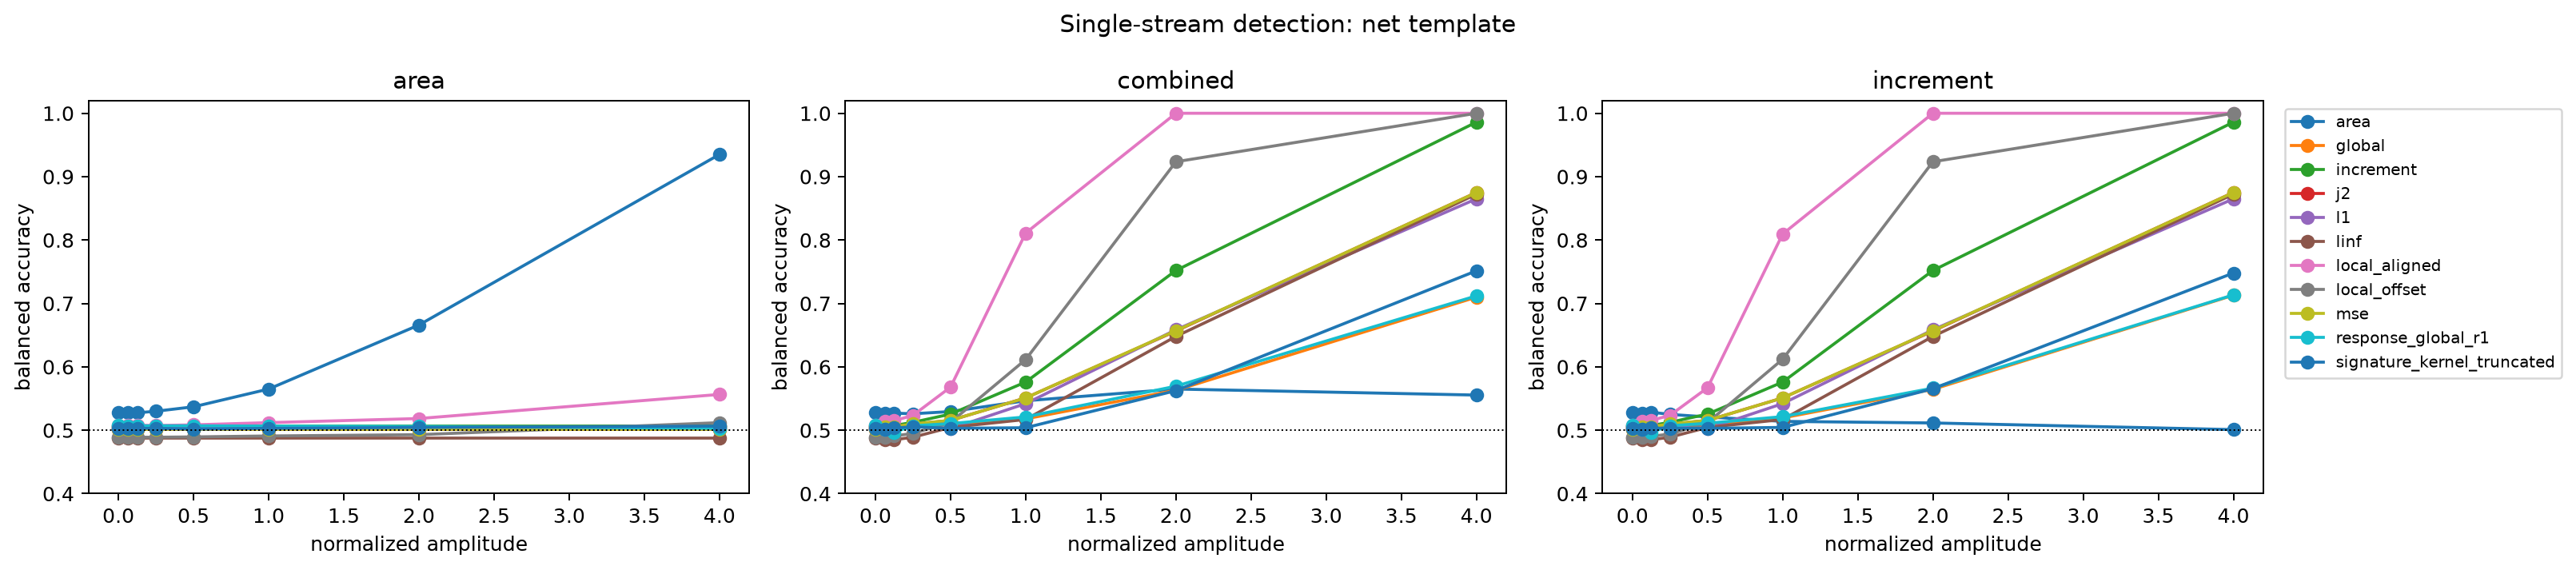

confirmation/figures/detection_net.png


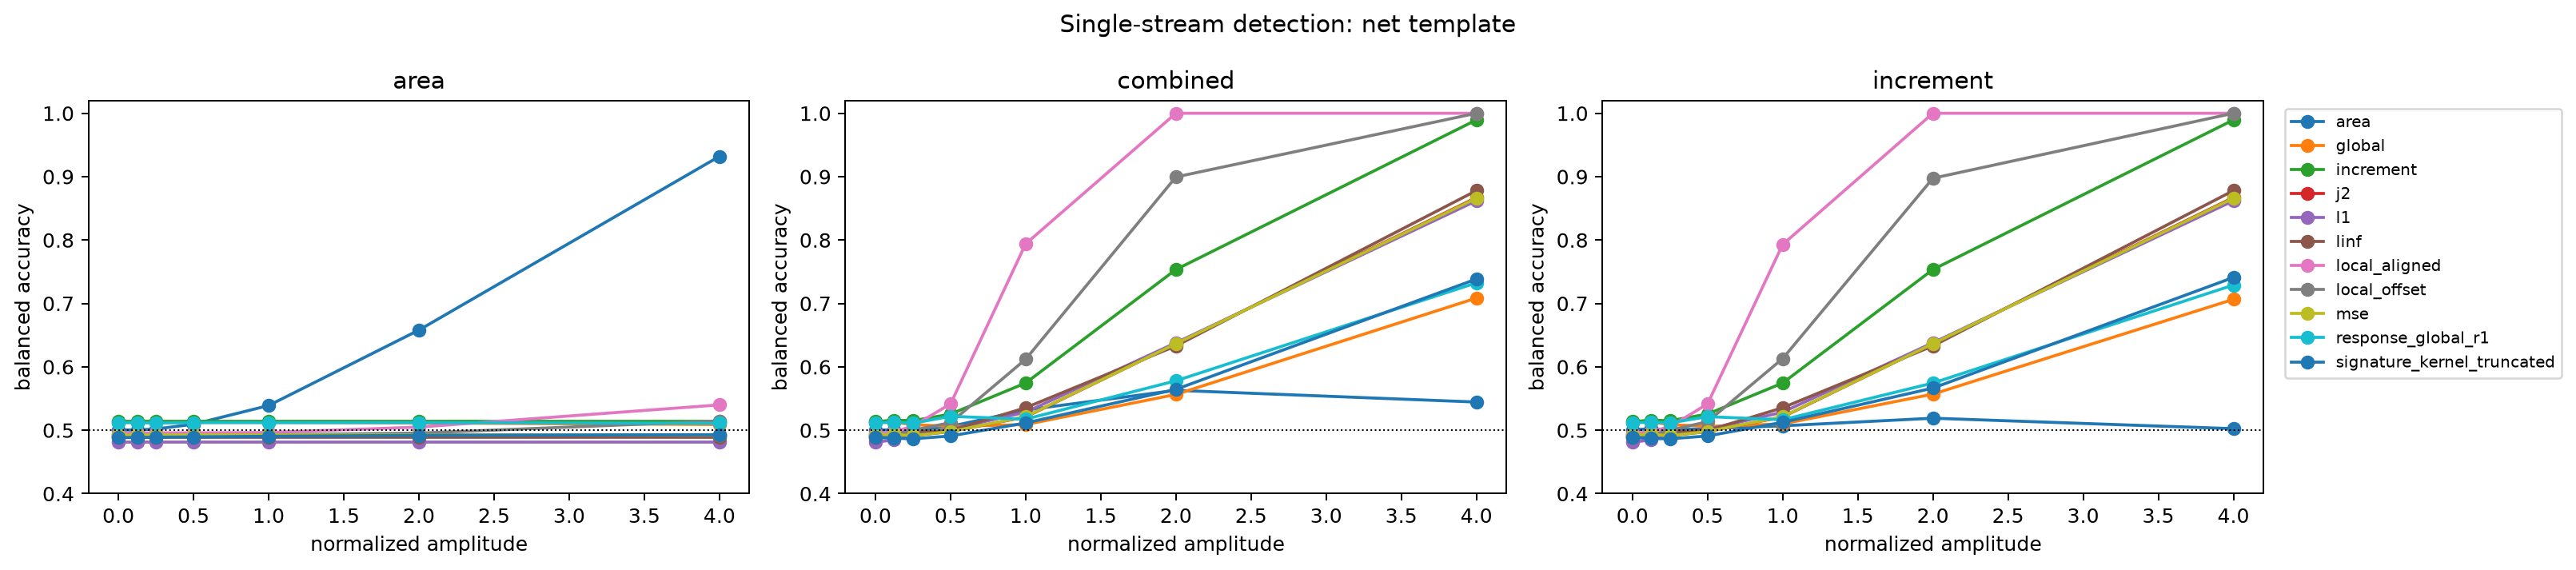

main/figures/detection_balanced.png


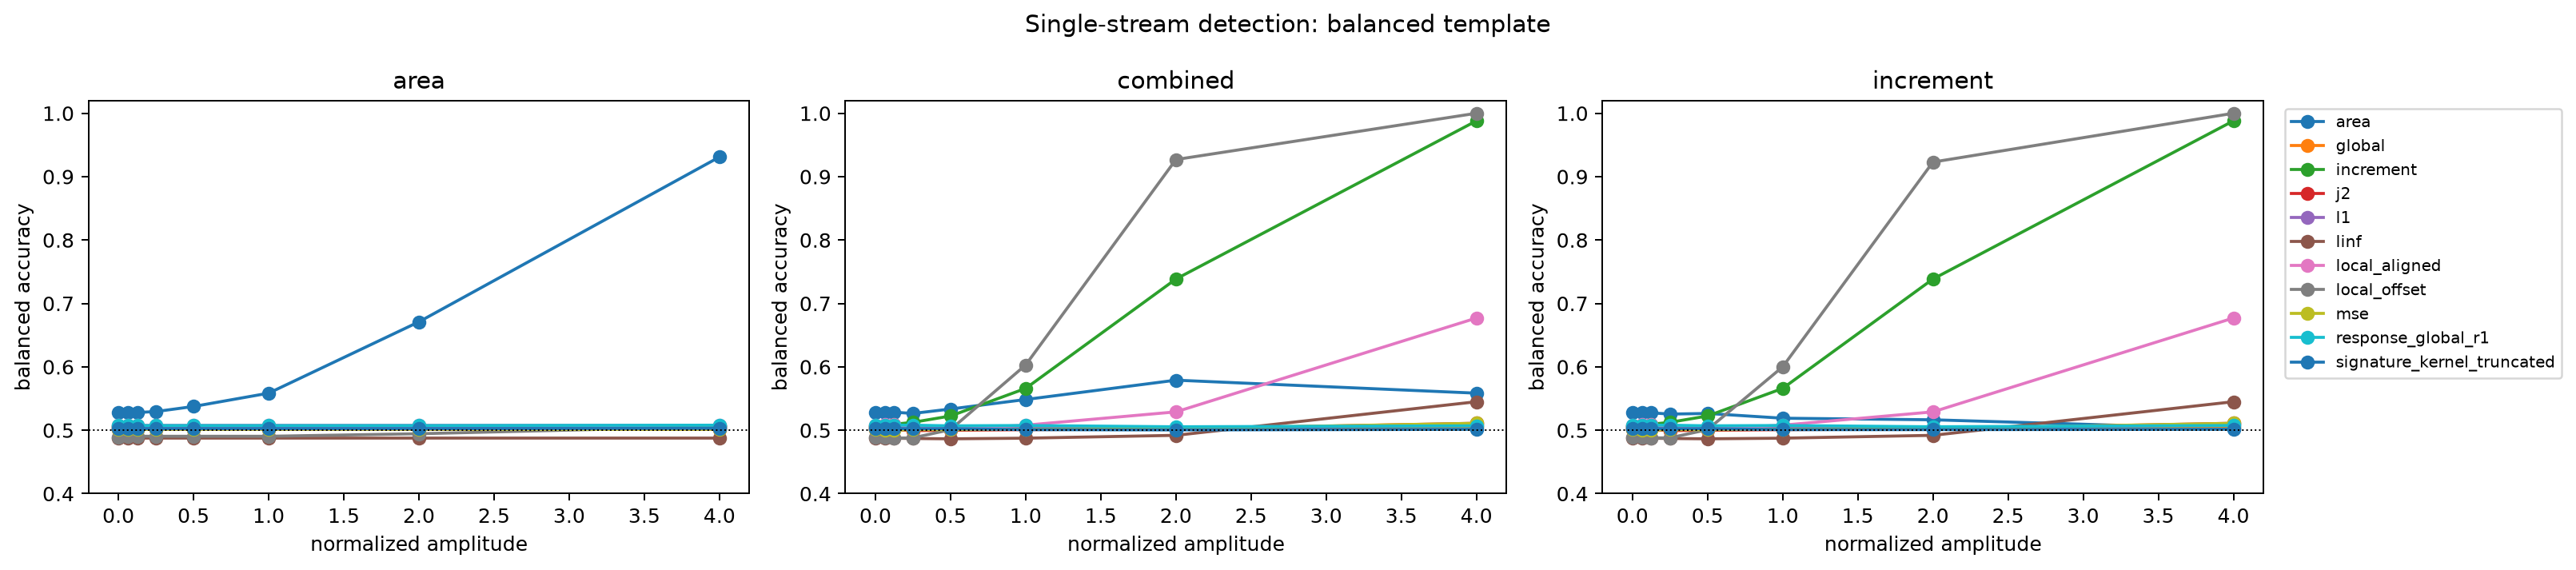

confirmation/figures/detection_balanced.png


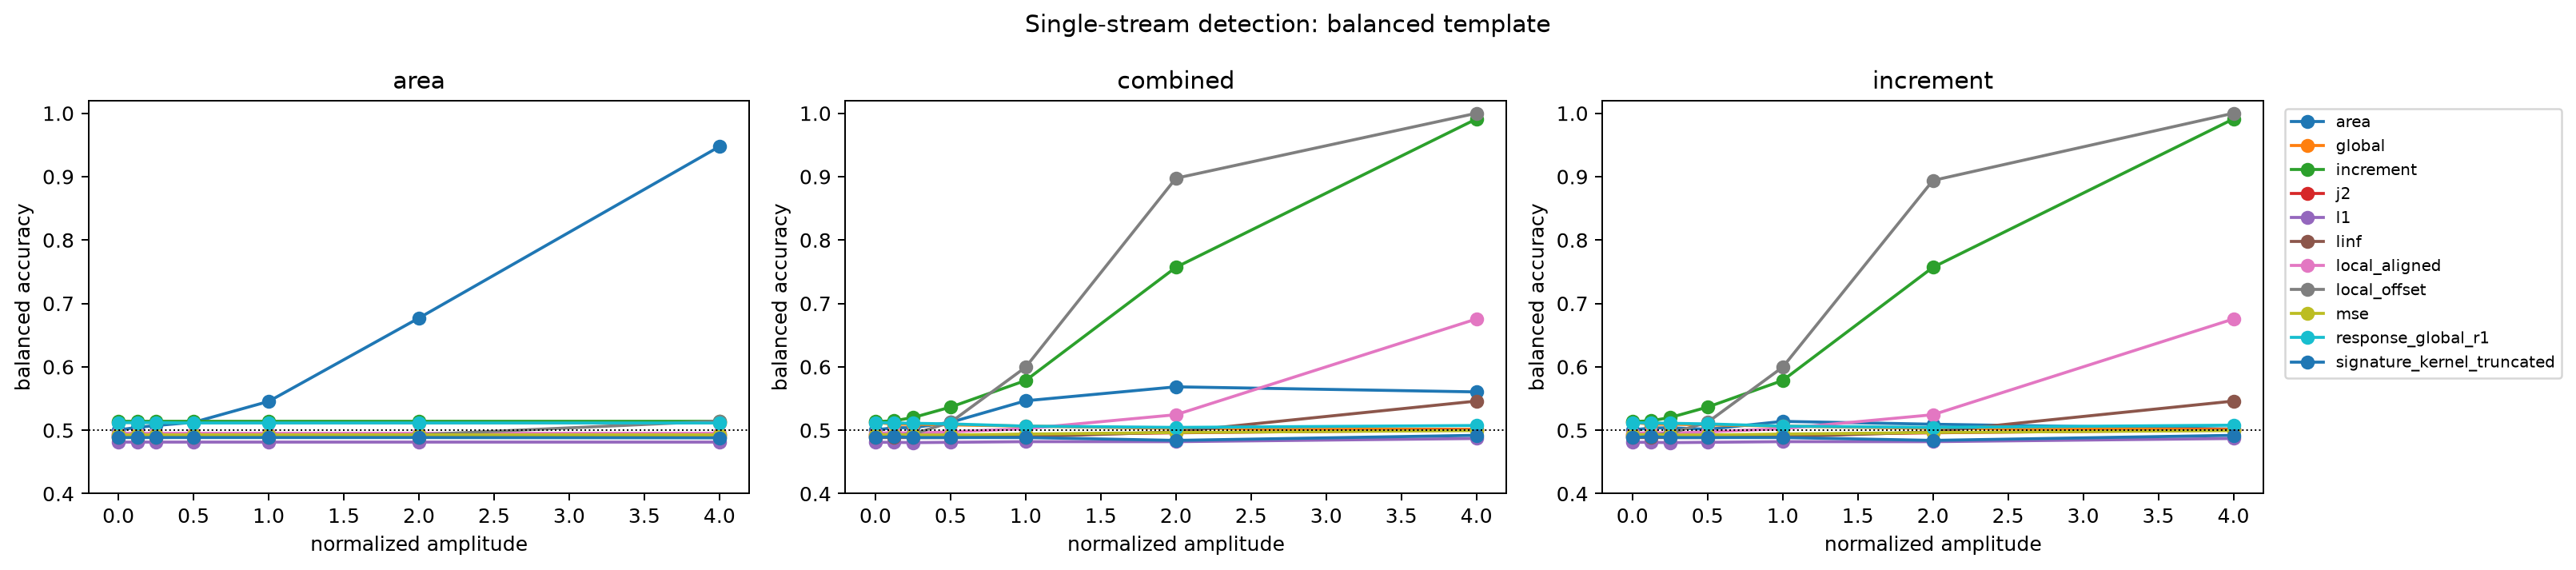

main/figures/balanced_area_components.png


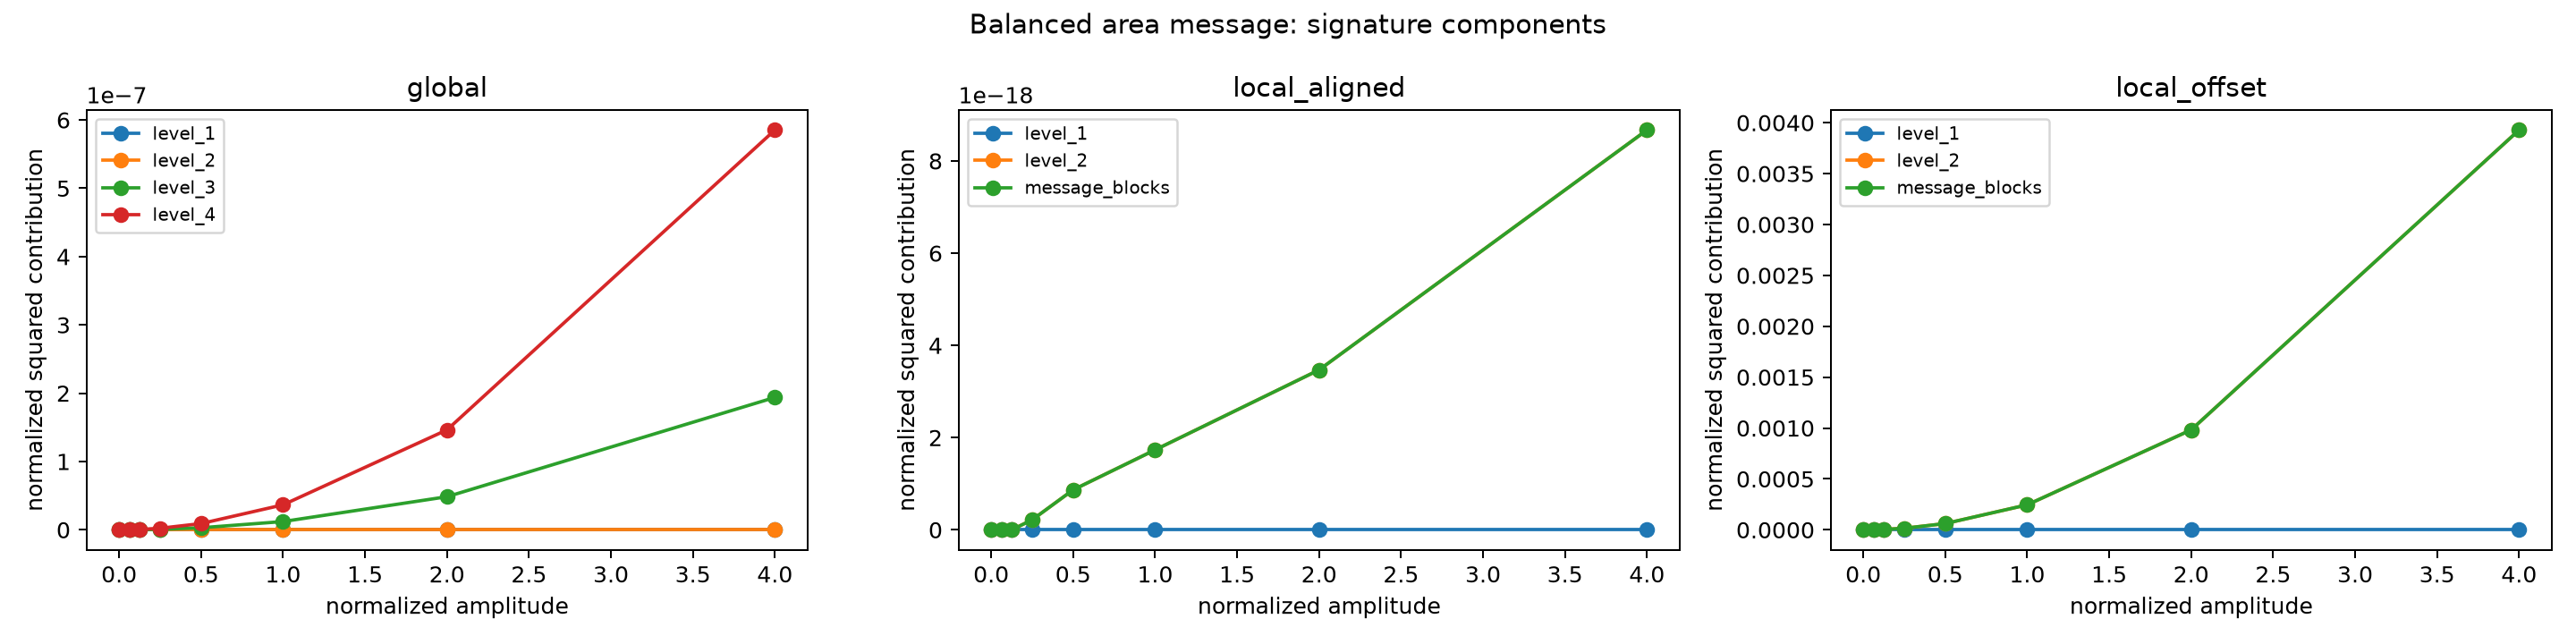

main/figures/four_class_net.png


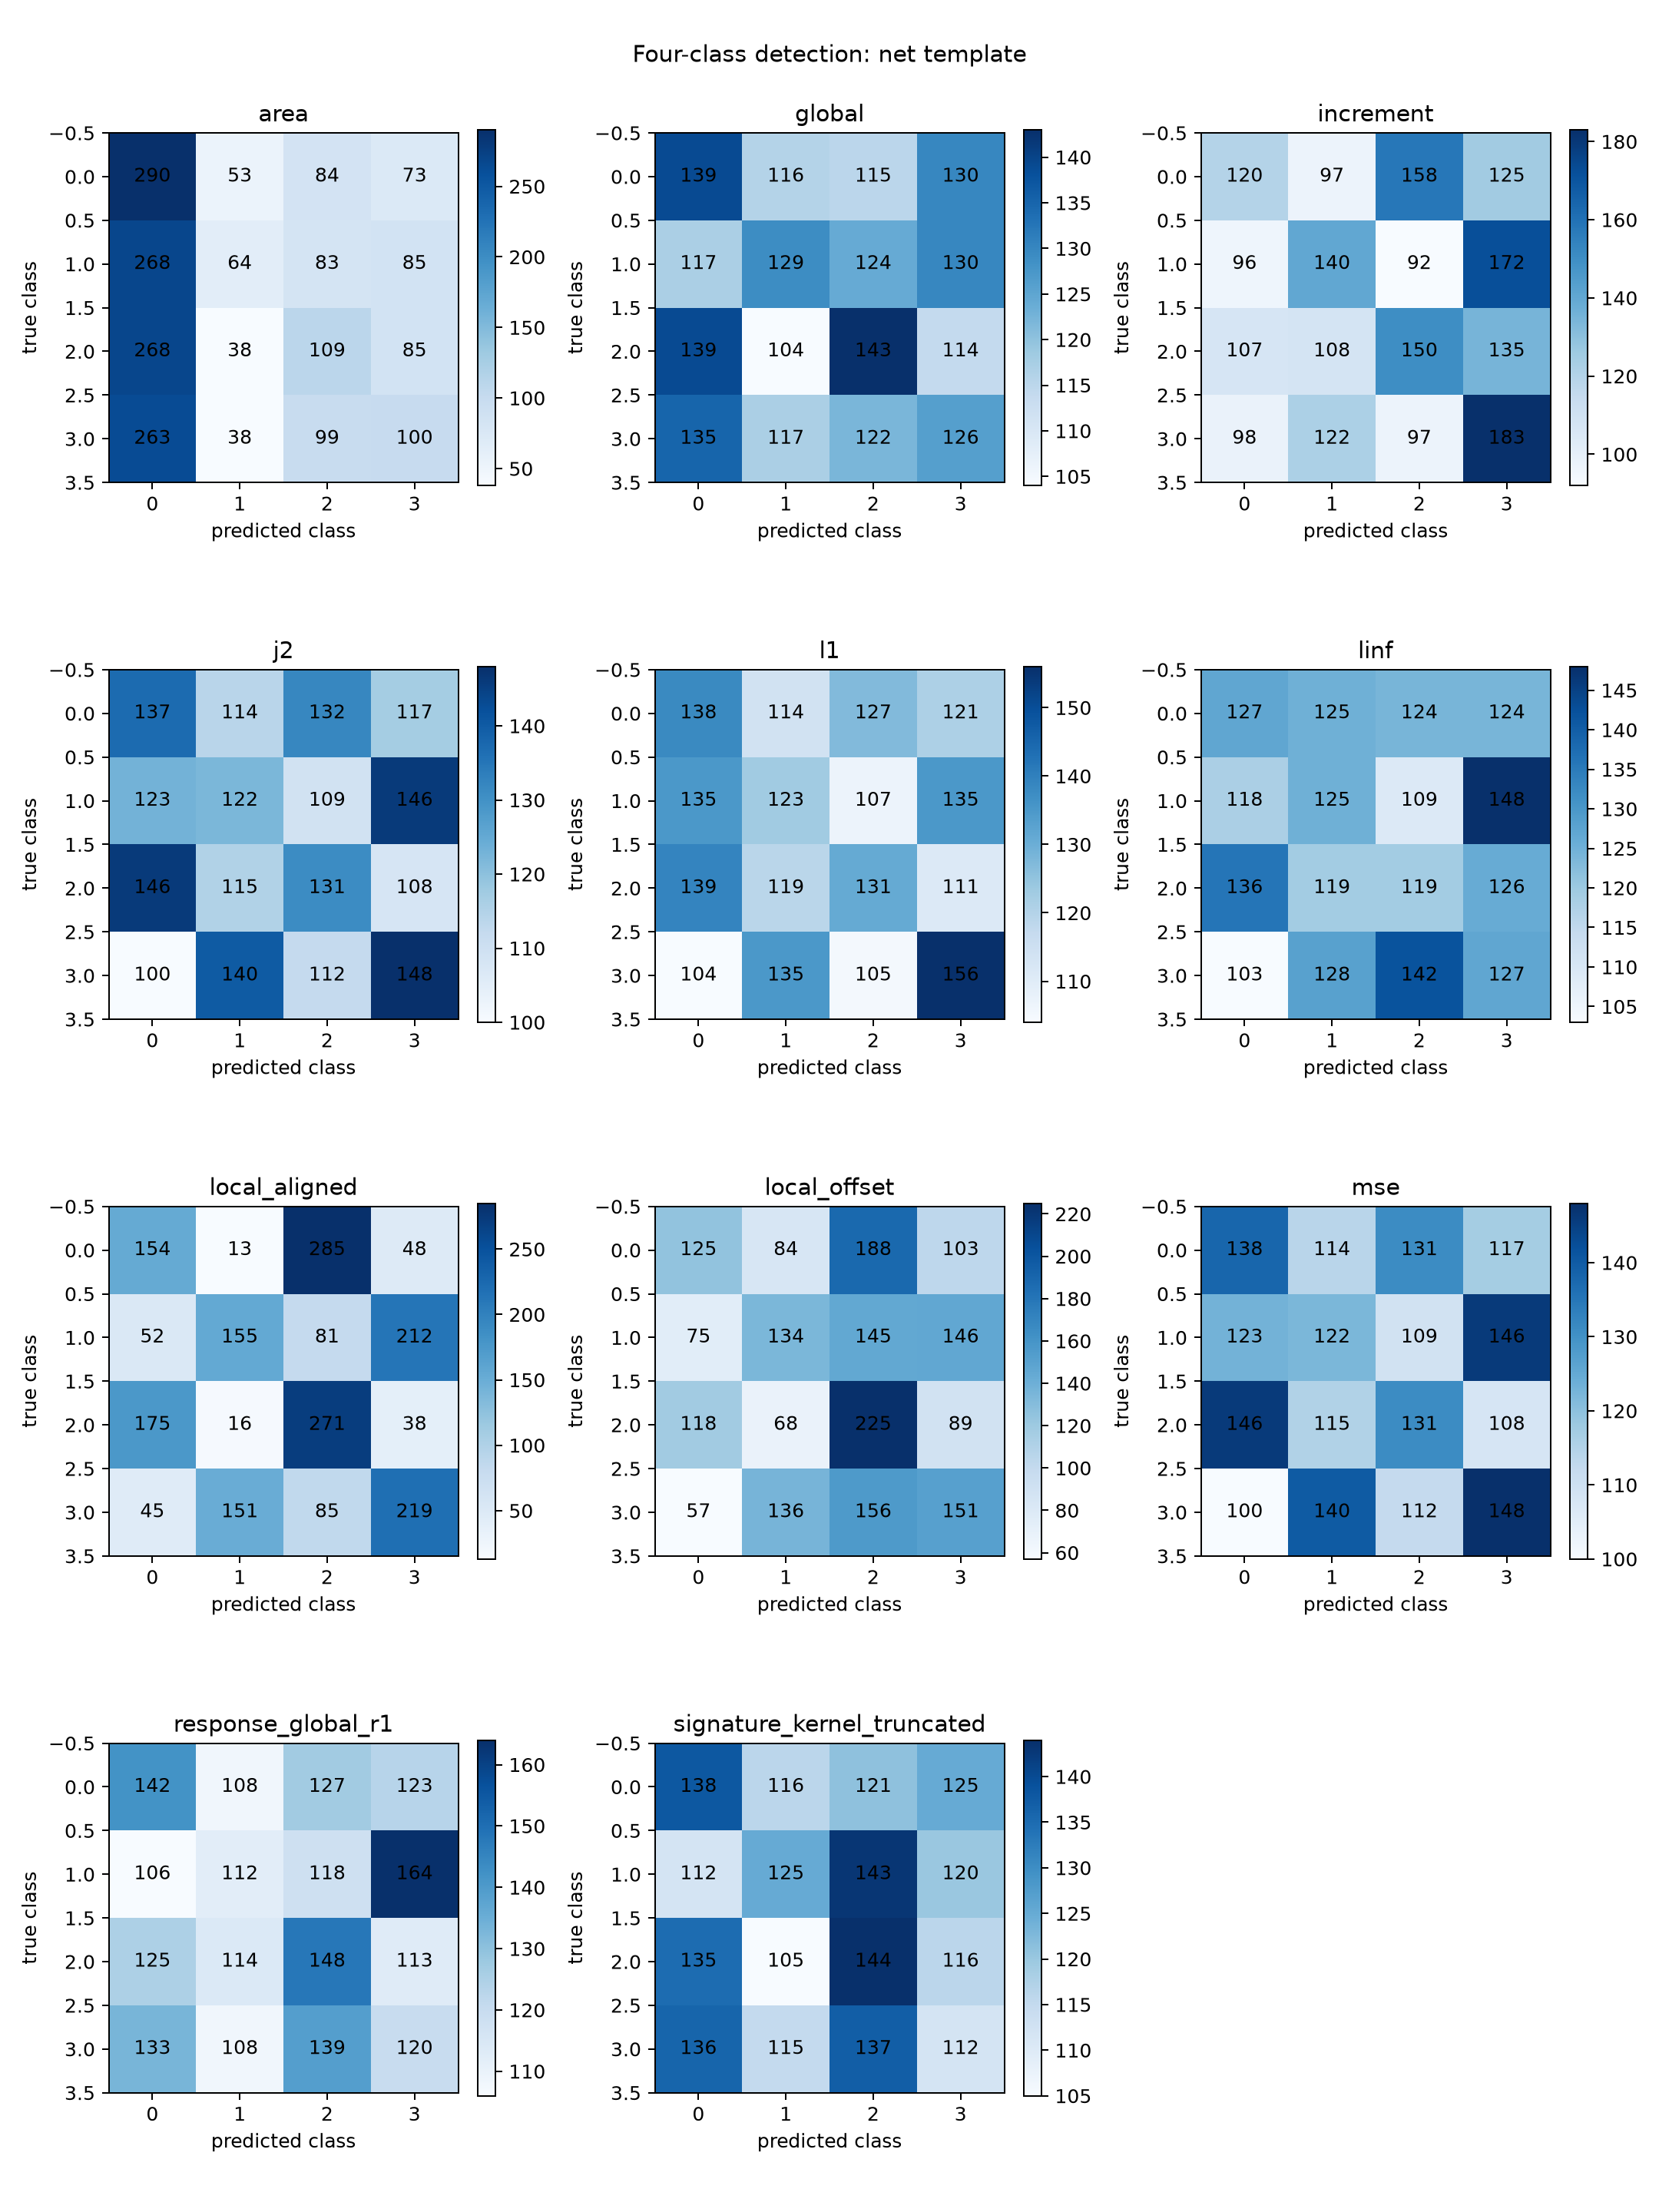

main/figures/four_class_balanced.png


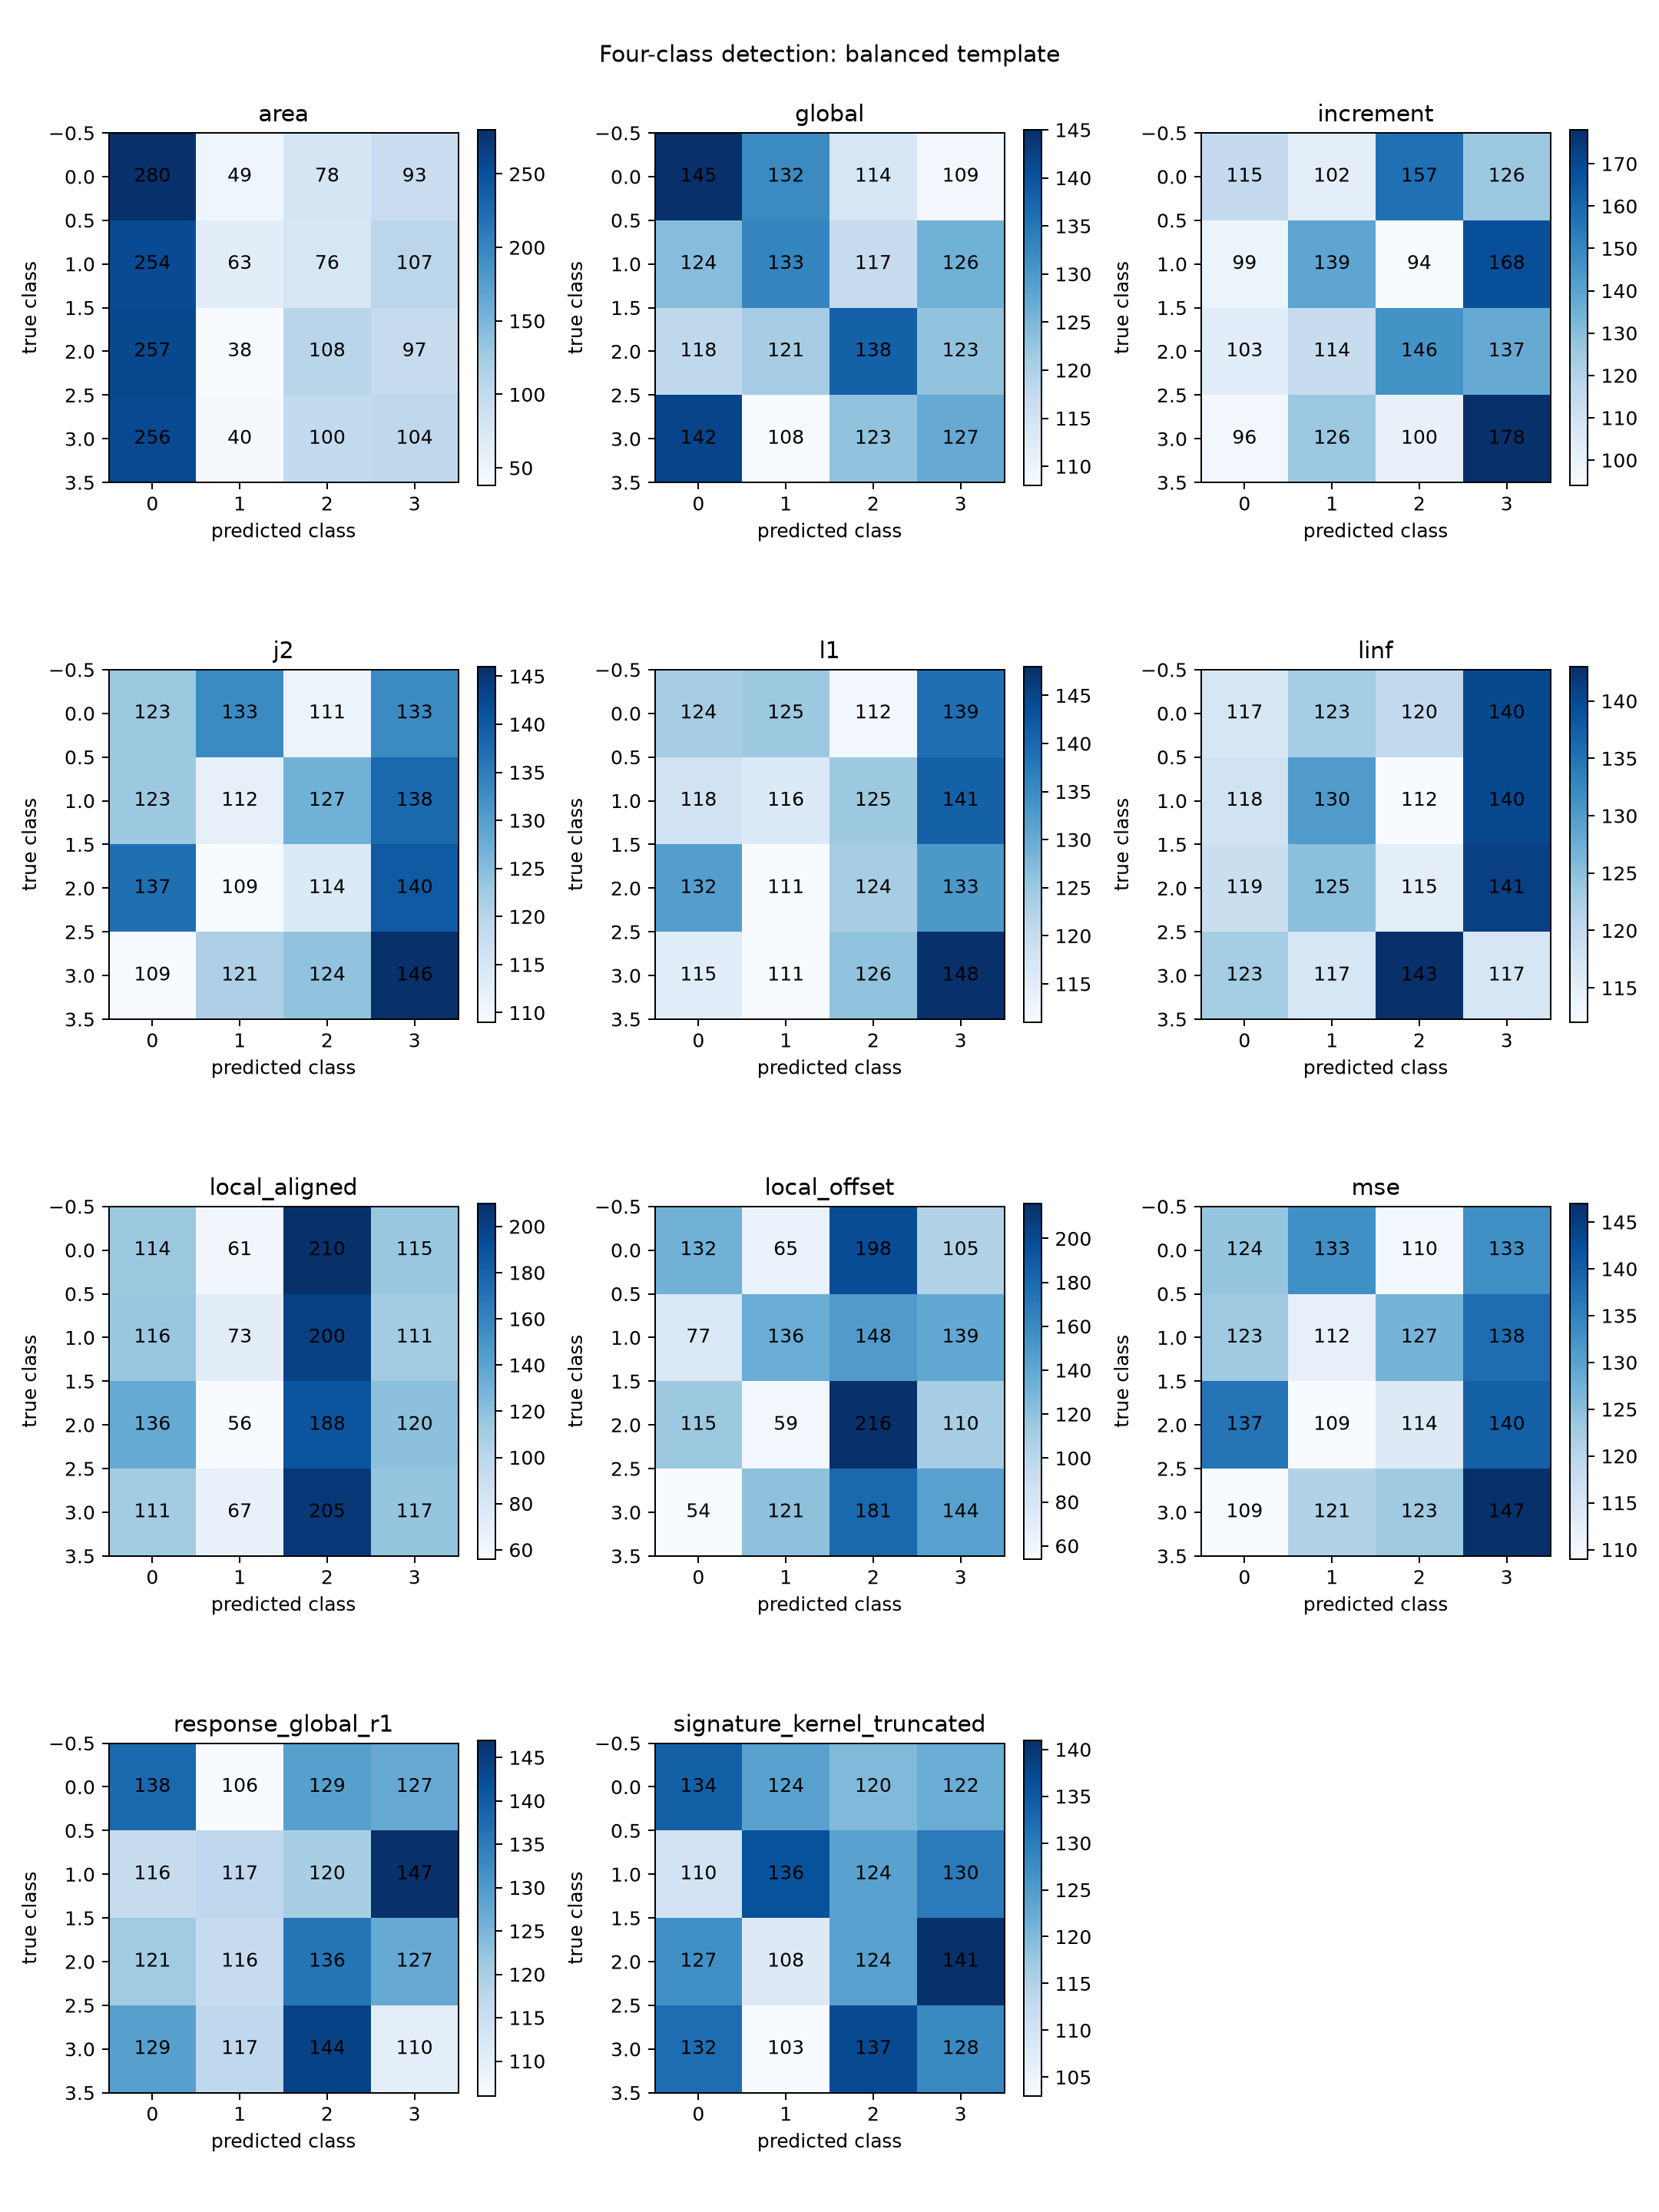

In [4]:
# Figures produced by the aggregation stage. Numerical tables are displayed
# once in the preceding cell.
figure_paths = [
    RESULT_ROOT / "main" / "figures" / "detection_net.png",
    RESULT_ROOT / "confirmation" / "figures" / "detection_net.png",
    RESULT_ROOT / "main" / "figures" / "detection_balanced.png",
    RESULT_ROOT / "confirmation" / "figures" / "detection_balanced.png",
    RESULT_ROOT / "main" / "figures" / "balanced_area_components.png",
    RESULT_ROOT / "main" / "figures" / "four_class_net.png",
    RESULT_ROOT / "main" / "figures" / "four_class_balanced.png",
]
for path in figure_paths:
    if path.exists():
        print(path.relative_to(RESULT_ROOT))
        display(Image(filename=str(path)))
